<hr style= "height:2px; background-color:black;">
<div style="text-align:center;"><h1>Retail Transactions & Customer Demographics Analysis</h1>

<br>
<h3 style="text-align:left"><i>Author: [Pantelatos Spyros]<br>  
Date:[March, 2026]  <br>
LinkedIn: [Link] | GitHub: [Link]</i></h3>
<br>

<h4 style="text-align:center; color:#ff4943"><u>Note: This notebook contains custom HTML styling and Plotly graphics. For the best viewing experience, use Jupyter Notebook!.</u></h4>
<br>
 
<hr style="height:1px; background-color:black; width:50%; margin-left:22.5%">        
<h2>Project Overview</h2>
<hr style="height:1px; background-color:black; width:50%; margin-left:22.5%"> 

<h3 style="text-align:center">This project analyzes over 2 million retail transactions to uncover purchasing trends and identify high-value customer segments based on household demographics. By merging daily transaction logs with customer profiles, the analysis provides actionable insights into sales growth, seasonal trends, and demographic purchasing power. Additionally, the project evaluates product-level performance, promotional discount efficiency, and identifies the key "whale" households driving top-line revenue.</h3>
<br>

<hr style="height:1px; background-color:black; width:50%; margin-left:22.5%"> 
<h2>Key Objectives</h2>
<hr style="height:1px; background-color:black; width:50%; margin-left:22.5%"> 

<h3 style="text-align:center">
<ul style="text-align:left">
    <li><dt><ins>Data Cleaning & Optimization:</ins></dt></li>
          <dd>Downcast data types and utilize categorical variables to reduce memory usage by over 20%, ensuring scalable analysis.</dd>
    <li><dt><ins>Feature Engineering & KPIs:</ins></dt></li>
          <dd>Engineer monetary discount columns to calculate real-world promotional efficiency, outlier anomalies, and baseline store metrics (Average Basket/Household Spend).</dd>
    <li><dt><ins>Time-Series Analysis:</ins></dt></li>
          <dd>Track monthly and daily sales trends, comparing performance across 2016 and 2017 to spot seasonal growth.</dd>
    <li><dt><ins>Customer & Product Profiling:</ins></dt></li>
          <dd>Isolate the Top 10 households and products by volume and sales, mapping raw transaction IDs to readable item descriptions.</dd>
    <li><dt><ins>Demographic Profiling:</ins></dt></li>
           <dd>Join transaction data with household demographics to evaluate how age, income brackets, and household composition impact total and average sales.</dd>
    <li><dt><ins>Reporting:</ins></dt></li>
          <dd>Aggregate findings into dynamic pivot tables and interactive charts exported for stakeholder review.</dd>
</ul></h3>

<hr style="height:1px; background-color:black; width:50%; margin-left:22.5%"> 
<h2>Tools & Techniques Demonstrated</h2>
<hr style="height:1px; background-color:black; width:50%; margin-left:22.5%">

<h3 style="text-align:left">
<ul>
    <li><dt><ins>Libraries:</ins></dt></li>
        <ul style="list-style-type:circle;">
            <li><dd>Python</dd></li>
            <li><dd>Pandas</dd></li>
            <li><dd>NumPy</dd></li>
            <li><dd>Plotly (Interactive Data Visualization)</dd></li>
            <li><dd>HTML (for markdowns)</dd></li>
        </ul>
</ul>
<ul>
    <li><dt><ins>Techniques:</ins></dt></li>
        <ul style="list-style-type:circle;">
            <li><dd>Memory Optimization</dd></li>
            <li><dd>Feature Engineering & Outlier Detection</dd></li>
            <li><dd>Time-Series Manipulation</dd></li>
            <li><dd>Relational Data Merging & Index Filtering</dd></li>
            <li><dd>Data Aggregation</dd></li>
            <li><dd>Pivot Tables</dd></li>
            <li><dd>Custom Pandas Display Formatting</dd></li>
        </ul>
</ul>
</h3>
</div>
<hr style= "height:2px; background-color:black; color:black;">


import notebook
print(notebook.__version__)

In [1]:
import pandas as pd
import numpy as np

In [2]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

<div>
    <h3 style="color:#ff9382"><i>**Data Engineering Note:**</i></h3>
    <h3>Since we are working on financial figures, we suppress Pandas' default scientific notation. All floating-point numbers are standardized to display exactly two decimal places (standard currency format) throughout the entire report.</h3>
</div>
<hr style="height:1px; background-color:black;">

<h2 style="text-align:center; background-color: #cee0ff">Step 1: Data Ingestion & Initial Inspection</h2>

In [3]:
df=pd.read_csv("project_transactions.csv")
df.head(5)

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,1364,26984896261,1,842930,1,2.19,31742,0.00,1,0.00,0.00
1,1364,26984896261,1,897044,1,2.99,31742,-0.40,1,0.00,0.00
2,1364,26984896261,1,920955,1,3.09,31742,0.00,1,0.00,0.00
3,1364,26984896261,1,937406,1,2.50,31742,-0.99,1,0.00,0.00
4,1364,26984896261,1,981760,1,0.60,31742,-0.79,1,0.00,0.00


<hr style="background-color:#9bc0ff; height:2px; width:50%; margin-left:22.5%">
<h3 style="text-align:center">Checking Missing Data</h3>
<hr style="background-color:#9bc0ff; height:2px; width:50%; margin-left:22.5%">

In [4]:
df.isna().sum()

household_key        0
BASKET_ID            0
DAY                  0
PRODUCT_ID           0
QUANTITY             0
SALES_VALUE          0
STORE_ID             0
RETAIL_DISC          0
WEEK_NO              0
COUPON_DISC          0
COUPON_MATCH_DISC    0
dtype: int64

<hr style="height:1px; background-color:black;">
<div>
    <h3 style="color:#8dcf63"><i>**Key Insight:**</i></h3>
    <h3>The scope of this dataset is massive. We are analyzing the purchasing behaviors of <b>2,099 unique households</b> interacting with a catalog of <b>84,138 unique products</b>. This level of granularity allows to build highly accurate demographic and product performance profiles.</h3>
</div>


In [5]:
print(f" Household has {df["household_key"].nunique()} unique entries in {len(df)}")

 Household has 2099 unique entries in 2146311


In [6]:
print(f" Product_ID has {df["PRODUCT_ID"].nunique()} unique entries in {len(df)}")

 Product_ID has 84138 unique entries in 2146311


<hr style="height:1px; background-color:black;">

<h2 style="text-align:center; background-color: #ceffed">Step 2: Memory Optimization & Data Downcasting</h2> 

In [7]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 2146311 entries, 0 to 2146310
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int64  
 3   PRODUCT_ID         int64  
 4   QUANTITY           int64  
 5   SALES_VALUE        float64
 6   STORE_ID           int64  
 7   RETAIL_DISC        float64
 8   WEEK_NO            int64  
 9   COUPON_DISC        float64
 10  COUPON_MATCH_DISC  float64
dtypes: float64(4), int64(7)
memory usage: 180.1 MB


In [8]:
df.describe().loc[["max"]].T.round() # All min/max values

,max
household_key,2099.00
BASKET_ID,42305362535.00
DAY,711.00
PRODUCT_ID,18316298.00
QUANTITY,89638.00
SALES_VALUE,840.00
STORE_ID,34280.00
RETAIL_DISC,4.00
WEEK_NO,102.00
COUPON_DISC,0.00


<div>
<h3 style="color:#ff9382"><i>**Data Engineering Note:**</i></h3>
<h3> <b>QUANTITY</b> max is 89638. We will later downcast this to `int32` to save memory since it easily fits within the 32-bit integer limits. Using the same way with the max value we will downcast <b>household key</b> and <b>WEEK_NO</b> as well</h3></div>
<hr style="height:1px; background-color:black">

In [9]:
df[["STORE_ID"]].nunique()

STORE_ID    526
dtype: int64

In [10]:
df[["STORE_ID"]].nunique()/len(df)*100

STORE_ID   0.02
dtype: float64

<div>
<h3 style="color:#ff9382"><i>**Data Engineering Note:**</i></h3>
<h3>Out of the 2,146,311 entries in the <b>STORE_ID</b> column, only 526 are unique (~0.02%). Casting this as a `Category` type will drastically reduce memory consumption.</h3></div>
<hr style="height:1px;background-color:black;">

In [11]:
df=df.astype({"household_key":"int16", "QUANTITY":"int32", "STORE_ID":"category","WEEK_NO":"int8"})

In [12]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 2146311 entries, 0 to 2146310
Data columns (total 11 columns):
 #   Column             Dtype   
---  ------             -----   
 0   household_key      int16   
 1   BASKET_ID          int64   
 2   DAY                int64   
 3   PRODUCT_ID         int64   
 4   QUANTITY           int32   
 5   SALES_VALUE        float64 
 6   STORE_ID           category
 7   RETAIL_DISC        float64 
 8   WEEK_NO            int8    
 9   COUPON_DISC        float64 
 10  COUPON_MATCH_DISC  float64 
dtypes: category(1), float64(4), int16(1), int32(1), int64(3), int8(1)
memory usage: 133.1 MB


<div>
<h3 style="color:#cfca63"><i>**Data Engineering Insight:**</i></h3>
<h3>By downcasting integer types and converting highly repetitive strings to Categorical data, we successfully reduced the DataFrame's memory footprint from <b>180.1 MB</b> to <b>133.1 MB</b> (a ~26% reduction).</h3></div>
<hr style= "height:1px; background-color:black;">

In [13]:
df[["DAY"]].info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 2146311 entries, 0 to 2146310
Data columns (total 1 columns):
 #   Column  Dtype
---  ------  -----
 0   DAY     int64
dtypes: int64(1)
memory usage: 16.4 MB


<div>
<h3 style="color:#ff9382"><i>**Data Engineering Note:**</i></h3>
<h3>The <b>DAY</b> column has an integer data type representing days passed. This will be converted to a `datetime64` object to enable proper time-series analysis.</h3></div>
<hr style="height:1px; background-color:black;">

In [14]:
df=(df
      .assign(date = (pd.to_datetime("2016", format='%Y') 
      + pd.to_timedelta(df["DAY"].sub(1).astype(str) + " days")))
      .drop(["DAY"], axis=1))

<div>
<h3 style="color:#ff9382"><i>**Data Engineering Note:**</i></h3>
<h3>We calculate the exact date for each transaction by adding the <b>DAY</b> 'timedelta' to our base date (Jan 1, 2016).</h3></div>
<hr style= "height:1px; background-color:black;">

In [15]:
df[["date"]]

,date
0,2016-01-01
1,2016-01-01
2,2016-01-01
3,2016-01-01
4,2016-01-01
...,...
2146306,2017-12-11
2146307,2017-12-11
2146308,2017-12-11
2146309,2017-12-11


In [16]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 2146311 entries, 0 to 2146310
Data columns (total 11 columns):
 #   Column             Dtype         
---  ------             -----         
 0   household_key      int16         
 1   BASKET_ID          int64         
 2   PRODUCT_ID         int64         
 3   QUANTITY           int32         
 4   SALES_VALUE        float64       
 5   STORE_ID           category      
 6   RETAIL_DISC        float64       
 7   WEEK_NO            int8          
 8   COUPON_DISC        float64       
 9   COUPON_MATCH_DISC  float64       
 10  date               datetime64[us]
dtypes: category(1), datetime64[us](1), float64(4), int16(1), int32(1), int64(2), int8(1)
memory usage: 133.1 MB


In [17]:
df

,household_key,BASKET_ID,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC,date
0,1364,26984896261,842930,1,2.19,31742,0.00,1,0.00,0.00,2016-01-01
1,1364,26984896261,897044,1,2.99,31742,-0.40,1,0.00,0.00,2016-01-01
2,1364,26984896261,920955,1,3.09,31742,0.00,1,0.00,0.00,2016-01-01
3,1364,26984896261,937406,1,2.50,31742,-0.99,1,0.00,0.00,2016-01-01
4,1364,26984896261,981760,1,0.60,31742,-0.79,1,0.00,0.00,2016-01-01
...,...,...,...,...,...,...,...,...,...,...,...
2146306,1598,42305362535,92130,1,0.99,3228,0.00,102,0.00,0.00,2017-12-11
2146307,1598,42305362535,114102,1,8.89,3228,0.00,102,0.00,0.00,2017-12-11
2146308,1598,42305362535,133449,1,6.99,3228,0.00,102,0.00,0.00,2017-12-11
2146309,1598,42305362535,6923644,1,4.50,3228,-0.49,102,0.00,0.00,2017-12-11


<h2 style="text-align:center; background-color: #82b0ff">Step 3: Feature Engineering & Baseline KPIs</h2>

<hr style="background-color:#4f90ff; height:2px; width:50%; margin-left:22.5%">
<h3 style="text-align:center">Calculating Total & Percentage Discounts</h3>
<hr style="background-color:#4f90ff; height:2px; width:50%; margin-left:22.5%">

In [18]:
df["Total_Discount"]=(df["RETAIL_DISC"]+df["COUPON_DISC"])
df[["Total_Discount"]]

,Total_Discount
0,0.00
1,-0.40
2,0.00
3,-0.99
4,-0.79
...,...
2146306,0.00
2146307,0.00
2146308,0.00
2146309,-0.49


In [19]:
df=df.assign(Percentage_Discount = 
                            np.where(df["SALES_VALUE"] != 0,
                                     (df["Total_Discount"] / df["SALES_VALUE"]).abs(), 0))

df[["Percentage_Discount"]]

,Percentage_Discount
0,0.00
1,0.13
2,0.00
3,0.40
4,1.32
...,...
2146306,0.00
2146307,0.00
2146308,0.00
2146309,0.11


<div>
    <h3 style="color:#ff9382"><i>**Data Engineering Note:**</i></h3>
    <h3>To streamline promotional analysis, we engineered <b>Total_Discount</b> and <b>Percentage_Discount</b> features. We applied absolute values to capture the true discount magnitude and capped the ratio at 100% to handle anomalies.</h3>
</div>
<hr style="height:1px; background-color:black;">

<hr style="background-color:#4f90ff; height:2px; width:50%; margin-left:22.5%">
<h3 style="text-align:center">Removing unnecessary Columns</h3>
<hr style="background-color:#4f90ff; height:2px; width:50%; margin-left:22.5%">

In [20]:
df=df.drop(["RETAIL_DISC", "COUPON_DISC", "COUPON_MATCH_DISC"],axis=1)
df

,household_key,BASKET_ID,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,WEEK_NO,date,Total_Discount,Percentage_Discount
0,1364,26984896261,842930,1,2.19,31742,1,2016-01-01,0.00,0.00
1,1364,26984896261,897044,1,2.99,31742,1,2016-01-01,-0.40,0.13
2,1364,26984896261,920955,1,3.09,31742,1,2016-01-01,0.00,0.00
3,1364,26984896261,937406,1,2.50,31742,1,2016-01-01,-0.99,0.40
4,1364,26984896261,981760,1,0.60,31742,1,2016-01-01,-0.79,1.32
...,...,...,...,...,...,...,...,...,...,...
2146306,1598,42305362535,92130,1,0.99,3228,102,2017-12-11,0.00,0.00
2146307,1598,42305362535,114102,1,8.89,3228,102,2017-12-11,0.00,0.00
2146308,1598,42305362535,133449,1,6.99,3228,102,2017-12-11,0.00,0.00
2146309,1598,42305362535,6923644,1,4.50,3228,102,2017-12-11,-0.49,0.11


<h2 style="text-align:center; background-color: #ff9282">Step 4: Overall Statistics</h2>  

<hr style="background-color:#ff664f; height:2px; width:50%; margin-left:25%;">
<h3 style="text-align:center">The Total Sales</h3>
<hr style="background-color:#ff664f; height:2px; width:50%; margin-left:25%;">

In [21]:
Total_Sales=df["SALES_VALUE"].sum()
print(f" Total Sales: {Total_Sales:,.2f}€")

 Total Sales: 6,666,243.50€


<hr style="background-color:#ff664f; height:2px; width:50%; margin-left:25%;">
<h3 style="text-align:center">Total Discount</h3>
<hr style="background-color:#ff664f; height:2px; width:50%; margin-left:25%;">

In [22]:
Total_Discount=df["Total_Discount"].sum()
print(f" Total Discount: {abs(Total_Discount):,.2f}€")

 Total Discount: 1,178,658.08€


<hr style="background-color:#ff664f; height:2px; width:50%; margin-left:25%;">
<h3 style="text-align:center">Overall Percentage Discount</h3>
<hr style="background-color:#ff664f; height:2px; width:50%; margin-left:25%;">

In [24]:
print(f" Overall percentage discount {abs(df["Total_Discount"].sum() / df["SALES_VALUE"].sum()):.2%}")

 Overall percentage discount 17.68%


<hr style="background-color:#ff664f; height:2px; width:50%; margin-left:25%;">
<h3 style="text-align:center">Total Quantity Sold </h3>
<hr style="background-color:#ff664f; height:2px; width:50%; margin-left:25%;">

In [25]:
Total_Quantity=df["QUANTITY"].sum()
print(f" Total Discount: {Total_Quantity:,.0f}")

 Total Discount: 216,713,611


<hr style="background-color:#ff664f; height:2px; width:50%; margin-left:25%;">
<h3 style="text-align:center">Max Quantity Sold in a Single Row & Discount Inspection</h3>
<hr style="background-color:#ff664f; height:2px; width:50%; margin-left:25%;">

In [26]:
df.loc[df["QUANTITY"].idxmax()].to_frame().T

,household_key,BASKET_ID,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,WEEK_NO,date,Total_Discount,Percentage_Discount
1442095,630,34749153595,6534178,89638,250.00,384,73,2017-05-17 00:00:00,-13.45,0.05


<div>
    <h3 style="color:#cfca63"><i>**Data Engineering Insight:**</i></h3>
    <h3>We isolated a massive single-transaction anomaly of <b>89,638 units</b>. However, the discount on this bulk purchase is barely <b>5%</b> (well below the 17.68% average). This indicates a high-volume, inelastic commodity (like Gasoline), rather than a data entry error.</h3>
</div>
<hr style="height:1px; background-color:black;">

<hr style="background-color:#ff664f; height:2px; width:50%; margin-left:25%;">
<h3 style="text-align:center">Total Sales Value per Basket</h3>
<hr style="background-color:#ff664f; height:2px; width:50%; margin-left:25%;">

In [27]:
print(f" The Total sales value per basket is {(df["SALES_VALUE"].sum() / df["BASKET_ID"].nunique()).round(2):,.2f}€")

 The Total sales value per basket is 28.62€


<hr style="background-color:#ff664f; height:2px; width:50%; margin-left:25%;">
<h3 style="text-align:center">Total Sales Value per Household</h3>
<hr style="background-color:#ff664f; height:2px; width:50%; margin-left:25%;">

In [28]:
print(f" The Total sales value per household is {(df["SALES_VALUE"].sum() / df["household_key"].nunique()).round(2):,.2f}€")

 The Total sales value per household is 3,175.91€


<h2 style="text-align:center; background-color: #ffcee0">Step 5: Time-Series Analysis of Sales Trends</h2>  

In [29]:
import plotly.express as px
import plotly.graph_objects as go

<div style="border-style:dashed; border-color: #727272">
<h2 style="text-align:center; background-color: #b4b4b4">Interactive Visualization Guide:</h2>
<h3>The charts in this report are powered by Plotly and are fully interactive! When viewing this notebook, you can:
<ul><br>
    <li>Toggle Data Series
        <ul>
            <li>Click on any item in the chart legend,if legend is available (e.g., "2016" or "2017") to hide or show that specific line</li> 
            <li>Double-click an item to isolate it.</li>
        </ul>    
    <li>Download as Image
        <ul>
            <li>Hover your mouse over the top-right corner of any graph to reveal the toolbar, and click the 'Camera icon' to instantly download the visualization as a PNG file.</li>
        </ul>    
</ul></h3>
</div>    

<hr style="background-color:#ff9bc0; height:2px; width:50%; margin-left:22.5%">
<h3 style="text-align:center">Plotting Monthly Sales</h3>
<hr style="background-color:#ff9bc0; height:2px; width:50%; margin-left:22.5%">

In [30]:
SbM = (df.set_index("date")
       .loc[:,["SALES_VALUE"]]
       .resample("ME")
       .sum()
       .reset_index()) #Plotly uses the "date" column, so we need to reset the index
SbM

,date,SALES_VALUE
0,2016-01-31,46557.97
1,2016-02-29,97315.16
2,2016-03-31,185521.82
3,2016-04-30,267801.38
4,2016-05-31,298319.14
5,2016-06-30,288952.45
6,2016-07-31,296488.02
7,2016-08-31,303951.35
8,2016-09-30,302040.56
9,2016-10-31,309962.42


In [31]:
SbM["text_label"]=SbM["date"].dt.month_name()
SbM.loc[SbM.index % 2 != 0, "text_label"] = "" 

<div>
<h3 style="color:#ff9382"><i>**Data Engineering Note:**</i></h3>
<h3>We created a text label column to display month names on every other entry to keep the Plotly visualization clean and readable.</h3></div>
<hr style= "height:1px; background-color:black;">

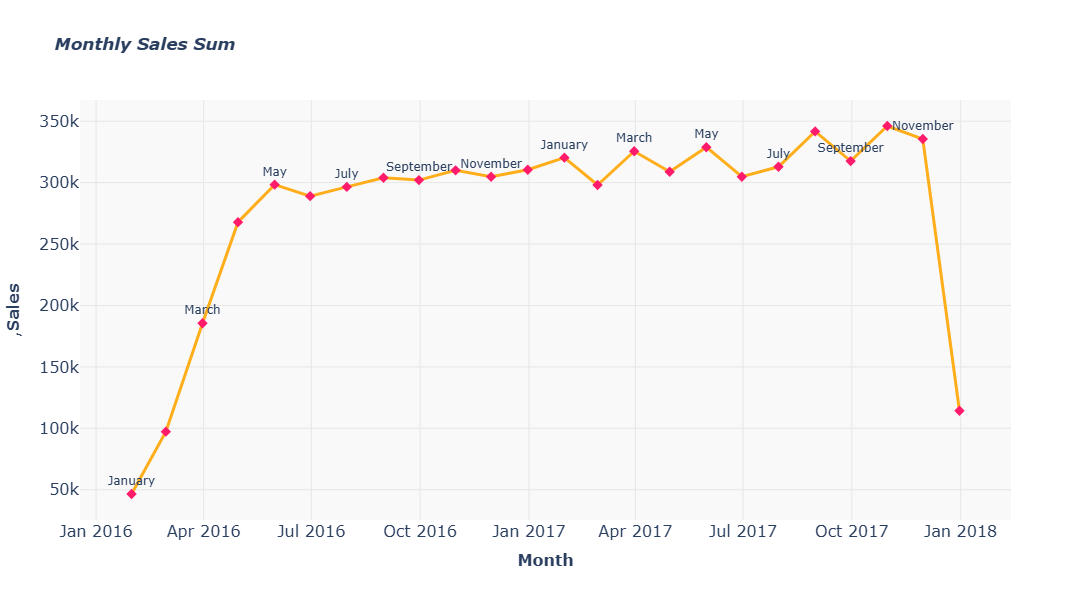

In [32]:
fig = px.line(SbM,
              x="date",
              y="SALES_VALUE",
              labels=dict(date= "<b>Month</b>", SALES_VALUE=",<b>Sales</b>"),
              text="text_label",
              title="<b><i>Monthly Sales Sum </b></i>",
              markers = True,
              color_discrete_sequence=["#ffae1b"])

fig.update_traces(line=dict(width = 3),
                  marker=dict(symbol="diamond", size=8, color="#ff1b6c"),
                  textposition='top center')
              
    
fig.update_layout(plot_bgcolor="#fafafa",          # Using the layout for axis titles font size
                  xaxis_title_font=dict(size=16),
                  yaxis_title_font=dict(size=16),
                  xaxis=dict(tickfont=dict(size=16)),
                  yaxis=dict(tickfont=dict(size=16)),
                  width=1000,
                  height=600)

fig.update_layout(xaxis=dict(showgrid=True, gridcolor="#e6e6e6"),   #Using the layout for grind colors
                  yaxis=dict(showgrid=True, gridcolor="#e6e6e6"),
                  plot_bgcolor="#f9f9f9")
fig.show()
fig.write_image("monthly_sales_trend.png", width=1200, height=800, scale=2) #Exporting the graph on .png file with code

<div>
<h3 style="color:#8dcf63"><i>**Key Insight:**</i></h3>
<h3>The monthly sales trend indicates significant fluctuations. While early 2016 shows lower sales, there is a strong upward shift entering the spring and summer months, plateauing around $300k-$340k monthly, before hitting a very low point at the end of 2017</h3></div>
<hr style= "height:1px; background-color:black;"> 

In [33]:
Growth=pd.DataFrame({"Month": SbM["date"],
                     "Sales_Growth_%":(SbM["SALES_VALUE"] / SbM["SALES_VALUE"].shift(1))
                     .sub(1)
                     .mul(100)
                     .round(2)
                     .astype(str) + "%"})
Growth

,Month,Sales_Growth_%
0,2016-01-31,NaN
1,2016-02-29,109.02%
2,2016-03-31,90.64%
3,2016-04-30,44.35%
4,2016-05-31,11.4%
5,2016-06-30,-3.14%
6,2016-07-31,2.61%
7,2016-08-31,2.52%
8,2016-09-30,-0.63%
9,2016-10-31,2.62%


<div>
<h3 style="color:#8dcf63"><i>**Key Insight:**</i></h3>
<h3>Although total sales are not showing consistent linear growth year-over-year, calculating the Month-over-Month percentage growth reveals strong seasonal shifts, particularly transitioning into early spring.</h3></div>
<hr style= "height:1px; background-color:black;">

<hr style="background-color:#ff9bc0; height:2px; width:50%; margin-left:22.5%">
<h3 style="text-align:center">Filtering Time-Series: April 2016 to October 2017</h3>
<hr style="background-color:#ff9bc0; height:2px; width:50%; margin-left:22.5%">

In [34]:
SbM2=SbM.set_index("date").loc["2016-04":"2017-10"].reset_index()
SbM2

,date,SALES_VALUE,text_label
0,2016-04-30,267801.38,
1,2016-05-31,298319.14,May
2,2016-06-30,288952.45,
3,2016-07-31,296488.02,July
4,2016-08-31,303951.35,
5,2016-09-30,302040.56,September
6,2016-10-31,309962.42,
7,2016-11-30,304764.41,November
8,2016-12-31,310456.27,
9,2017-01-31,320301.20,January


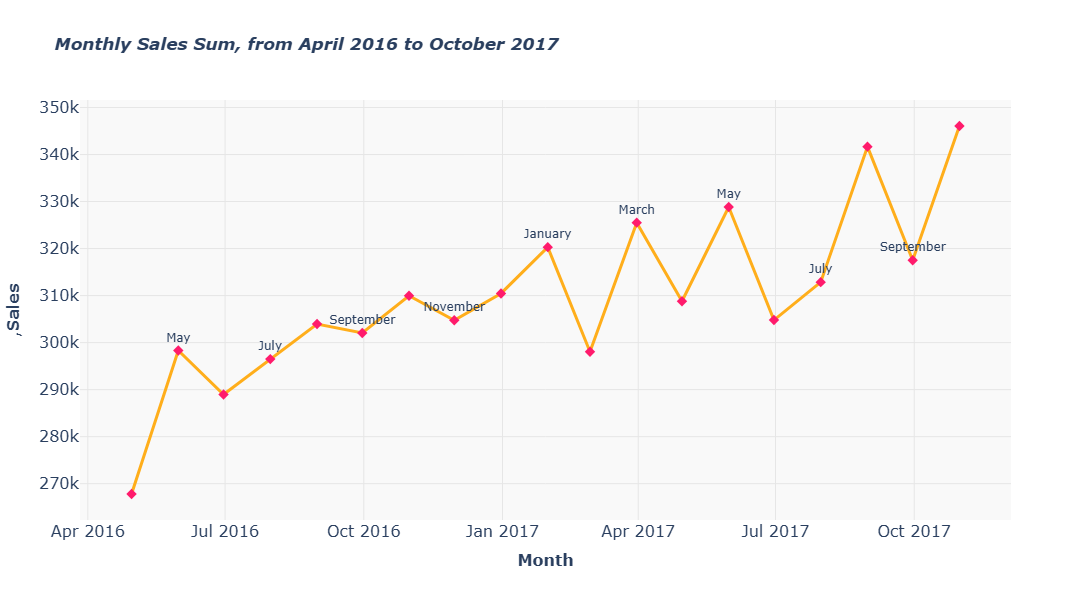

In [35]:
fig = px.line(SbM2,
              x="date",
              y="SALES_VALUE",
              labels=dict(date="<b>Month</b>", SALES_VALUE=",<b>Sales</b>"),
              text="text_label",
              title="<b><i>Monthly Sales Sum, from April 2016 to October 2017 </b></i>",
              markers = True,
              color_discrete_sequence=["#ffae1b"])

fig.update_traces(line=dict(width = 3),
                  marker=dict(symbol="diamond", size=8, color="#ff1b6c"),
                  textposition='top center')
               
    
fig.update_layout(plot_bgcolor="#fafafa",
                  xaxis_title_font=dict(size=16),
                  yaxis_title_font=dict(size=16),
                  xaxis=dict(tickfont=dict(size=16)),
                  yaxis=dict(tickfont=dict(size=16)),
                  width=1000,
                  height=600)

fig.update_layout(xaxis=dict(showgrid=True, gridcolor="#e6e6e6"),
                  yaxis=dict(showgrid=True, gridcolor="#e6e6e6"),
                  plot_bgcolor="#f9f9f9")
fig.show()
fig.write_image("April 1026 to Octomber 2107_trend.png", 
                width=1200, 
                height=800, 
                scale=2) #Exporting the graph on .png file with code

<div>
<h3 style="color:#8dcf63"><i>**Key Insight:**</i></h3>
<h3>"Zooming in", we can see the fluctuations more clearly.Starting from January 2017,the gap between months started increasing gradually from 20k to 30k.</h3></div>
<hr style= "height:1px;background-color:black;"> 

<hr style="background-color:#ff9bc0; height:2px; width:50%; margin-left:22.5%">
<h3 style="text-align:center">Year-over-Year (YoY) Sales Comparison: 2016 vs 2017</h3>
<hr style="background-color:#ff9bc0; height:2px; width:50%; margin-left:22.5%">

In [36]:
SbY = (SbM
        .assign(Year=SbM["date"].dt.year)
        .query("Year in [2016, 2017]"))

In [37]:
SbY["Month"]=SbM["date"].dt.month_name()

In [38]:
SbY

,date,SALES_VALUE,text_label,Year,Month
0,2016-01-31,46557.97,January,2016,January
1,2016-02-29,97315.16,,2016,February
2,2016-03-31,185521.82,March,2016,March
3,2016-04-30,267801.38,,2016,April
4,2016-05-31,298319.14,May,2016,May
5,2016-06-30,288952.45,,2016,June
6,2016-07-31,296488.02,July,2016,July
7,2016-08-31,303951.35,,2016,August
8,2016-09-30,302040.56,September,2016,September
9,2016-10-31,309962.42,,2016,October


<div>
<h3 style="color:#ff9382"><i>**Data Engineering Note:**</i></h3>
<h3>To plot 2016 and 2017 separately, we extracted the year and month into discrete columns. This allows Plotly to map overlapping series for a direct YoY comparison.</h3></div>
<hr style= "height:1px; background-color:black;">

In [39]:
SbY.groupby([SbY["Year"],SbY["Month"]]).agg({"SALES_VALUE":"sum"})

SALES_VALUE
Year Month                 
2016 April        267801.38
     August       303951.35
     December     310456.27
     February      97315.16
     January       46557.97
     July         296488.02
     June         288952.45
     March        185521.82
     May          298319.14
     November     304764.41
     October      309962.42
     September    302040.56
2017 April        308786.99
     August       341670.16
     December     114286.55
     February     298058.26
     January      320301.20
     July         312853.52
     June         304792.96
     March        325511.23
     May          328829.68
     November     335458.18
     October      346065.23
     September    317498.59

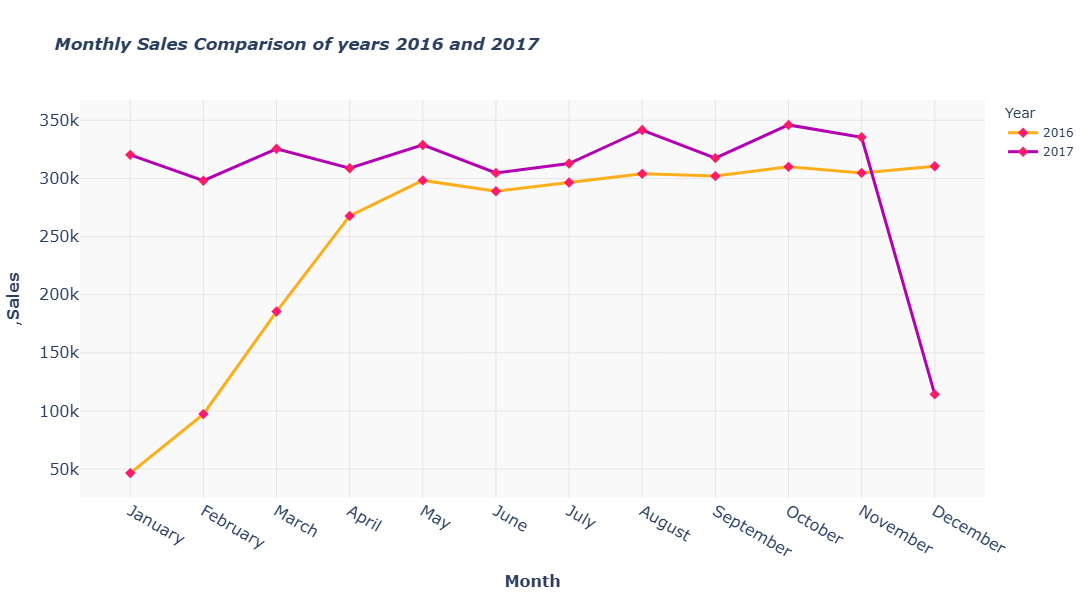

In [40]:
fig = px.line(SbY,
               x="Month",
               y="SALES_VALUE",
               color="Year",
               markers=True,
               labels=dict(Month= "<b>Month</b>", SALES_VALUE=",<b>Sales</b>"),
               title="<b><i>Monthly Sales Comparison of years 2016 and 2017 </b></i>",
               color_discrete_map={2016: "#ffae1b", 2017: "#b300b3"})

fig.update_traces(line=dict(width = 3),
                   marker=dict(symbol="diamond",size=8,color="#ff1b6c"))
              

fig.update_layout(plot_bgcolor="#fafafa",
                   xaxis_title_font=dict(size=16),
                   yaxis_title_font=dict(size=16),
                   xaxis=dict(tickmode="linear", dtick=1, tickfont=dict(size=16)),
                   yaxis=dict(tickfont=dict(size=16)),
                   legend_title_text="Year",
                   width=1000,
                   height=600)
                  

fig.update_layout(xaxis=dict(showgrid=True, gridcolor="#e6e6e6"),
                  yaxis=dict(showgrid=True, gridcolor="#e6e6e6"),
                  plot_bgcolor="#f9f9f9")

fig.show()
fig.write_image("2016-2017 comparison.png", width=1200, height=800, scale=2) #Exporting the graph on .png file with code

<div>
<h3 style="color:#8dcf63"><i>**Key Insight:**</i></h3>
<h3>The Year-over-Year comparison clearly demonstrates that 2017 outperformed 2016 across almost all matched months, indicating healthy overall business growth despite internal month-to-month volatility, reaching it's lowest by the end of the year, still more than double the amount at the start of 2016.</h3></div>
<hr style= "height:1px; background-color:black;"> 

<hr style="background-color:#ff9bc0; height:2px; width:50%; margin-left:22.5%">
<h3 style="text-align:center">Daily Sales Volume Analysis</h3>
<hr style="background-color:#ff9bc0; height:2px; width:50%; margin-left:22.5%">

In [41]:
SbD=(df
    .assign(DayName=df["date"].dt.day_name(), DayNumber=df["date"].dt.dayofweek)
    .groupby(["DayNumber", "DayName"])["SALES_VALUE"]
    .sum()
    .round(2)
    .reset_index()
    .sort_values("DayNumber"))

SbD

,DayNumber,DayName,SALES_VALUE
0,0,Monday,1136462.30
1,1,Tuesday,1172457.99
2,2,Wednesday,920957.10
3,3,Thursday,839884.07
4,4,Friday,832957.98
5,5,Saturday,833944.67
6,6,Sunday,929579.39


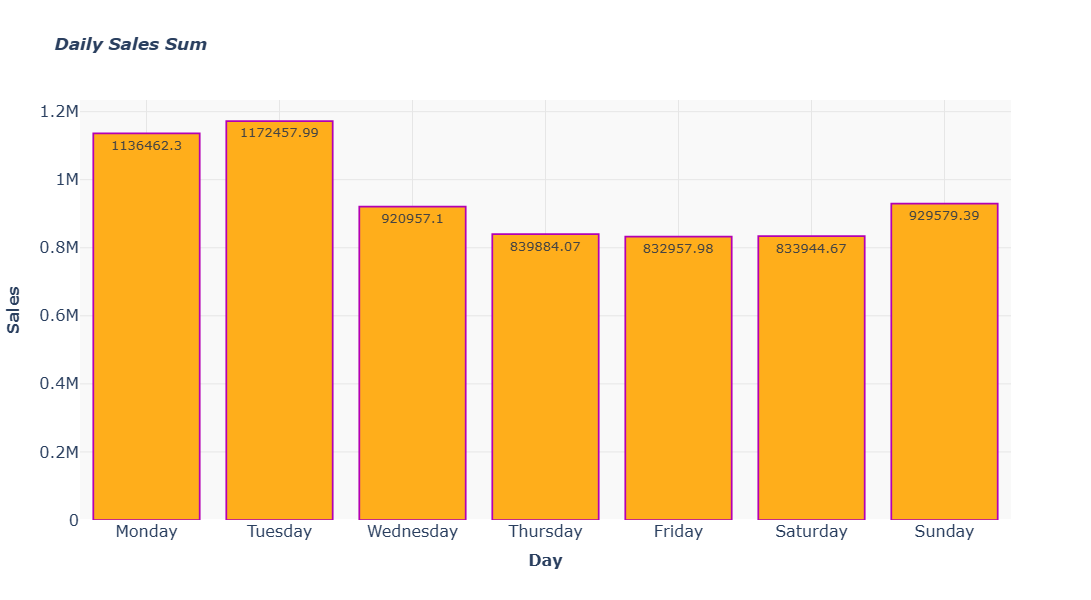

In [42]:
fig = px.bar(SbD,
              x= "DayName",
              y="SALES_VALUE",
              labels=dict(DayName="<b>Day</b>", SALES_VALUE="<b>Sales</b>"),
              text="SALES_VALUE",
              title="<b><i>Daily Sales Sum</b></i>",
             
              color_discrete_sequence=["#ffae1b"])

fig.update_traces(base=dict(
                    width = 3),
                    marker_line_color="#b300b3",
                    marker_line_width=1.75,
                    textfont_size=13)
        
               
    
fig.update_layout(plot_bgcolor="#fafafa",
                  xaxis_title_font=dict(size=16),
                  yaxis_title_font=dict(size=16),
                  xaxis=dict(tickfont=dict(size=16)),
                  yaxis=dict(tickfont=dict(size=16)),
                  width=1000,
                  height=600)

fig.update_layout(xaxis=dict(showgrid=True, gridcolor="#e6e6e6"),
                  yaxis=dict(showgrid=True, gridcolor="#e6e6e6"),
                  plot_bgcolor="#f9f9f9")
fig.show()
fig.write_image("Sales by Day.png", width=1200, height=800, scale=2) #Exporting the graph on .png file with code

<div>
<h3 style="color:#8dcf63"><i>**Key Insight:**</i></h3>
<h3>The daily sales breakdown reveals that Tuesdays and Mondays drive the highest volume of sales. Conversely, Fridays and Saturdays see a noticeable dip. This indicates a strong preference for early-week shopping. Marketing promotions or flash sales could be strategically shifted to the weekend to boost slower days.</h3></div>
<hr style= "height:1px; background-color:black;"> 


<h2 style="text-align:center; background-color:#62ab6c">Step 6: Household Analysis</h2>

<hr style="background-color:#4c8e55; height:2px; width:50%; margin-left:25%;">
<h3 style="text-align:center">Distribution of Total Sales Value per Household</h3>
<hr style="background-color:#4c8e55; height:2px; width:50%; margin-left:25%;">

In [43]:
SpHL=df.groupby(["household_key"])[["SALES_VALUE"]].sum().reset_index()
SpHL

,household_key,SALES_VALUE
0,1,4330.16
1,2,1954.34
2,3,2653.21
3,4,1200.11
4,5,779.06
...,...,...
2094,2095,3790.49
2095,2096,1301.65
2096,2097,8823.83
2097,2098,682.46


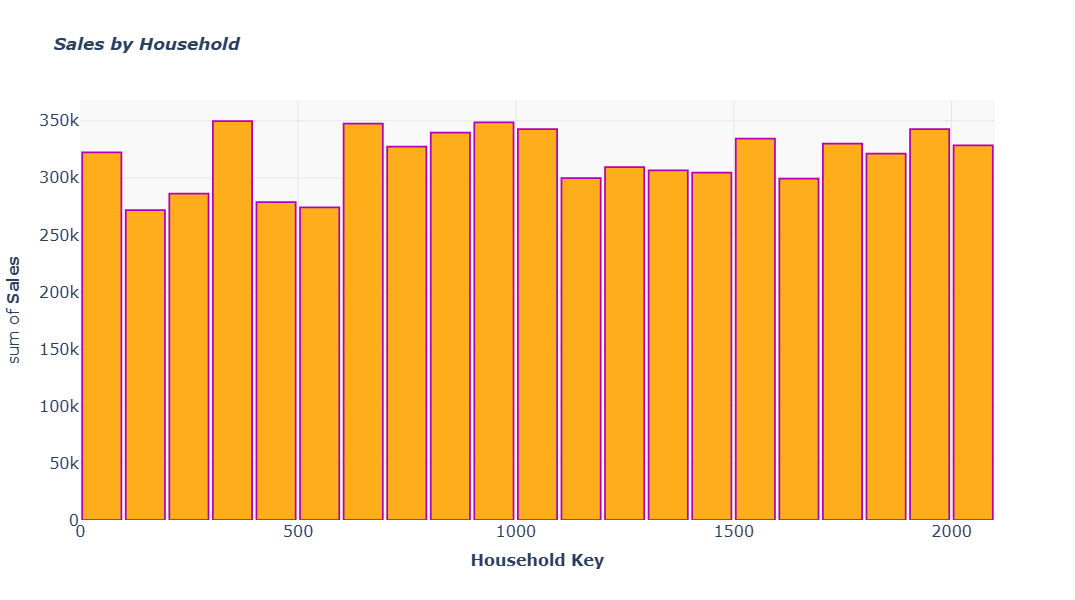

In [44]:
fig = px.histogram(SpHL,
              x= "household_key",
              y="SALES_VALUE",
              labels=dict(household_key="<b>Household Key</b>", SALES_VALUE="<b>Sales</b>"),
              title="<b><i>Sales by Household</b></i>",
              color_discrete_sequence=["#ffae1b"])

fig.update_traces(marker_line_color="#b300b3", marker_line_width=1.75)
        
    
fig.update_layout(plot_bgcolor="#fafafa",
                  xaxis_title_font=dict(size=16),
                  yaxis_title_font=dict(size=16),
                  xaxis=dict(tickfont=dict(size=16)),
                  yaxis=dict(tickfont=dict(size=16)),
                  bargap=0.1,
                  width=1000,
                  height=600)

fig.update_layout(xaxis=dict(showgrid=True, gridcolor="#e6e6e6"),
                  yaxis=dict(showgrid=True, gridcolor="#e6e6e6"),
                  plot_bgcolor="#f9f9f9")
fig.show()
fig.write_image("Sales by Household.png", width=1200, height=800, scale=2) #Exporting the graph on .png file with code

<hr style="background-color:#4c8e55; height:2px; width:50%; margin-left:25%;">
<h3 style="text-align:center">Top 10 Households by Quantity Purchased</h3>
<hr style="background-color:#4c8e55; height:2px; width:50%; margin-left:25%;">

In [45]:
Top10_Quantity=(df
                .groupby(["household_key"])[["QUANTITY"]]
                .sum()
                .sort_values(by=["QUANTITY"],ascending=False)
                .head(10))
                
Top10_Quantity

,QUANTITY
household_key,
1023,4479917
755,3141769
1609,2146715
13,1863829
1430,1741892
1527,1734632
1762,1669880
707,1640193
1029,1496204


<hr style="background-color:#4c8e55; height:2px; width:50%; margin-left:25%;">
<h3 style="text-align:center">Top 10 Households by Sales Value</h3>
<hr style="background-color:#4c8e55; height:2px; width:50%; margin-left:25%;">

In [46]:
Top10_Sales =(df
                .groupby(["household_key"])[["SALES_VALUE"]]
                .sum()
                .sort_values(by=["SALES_VALUE"],ascending=False)
                .head(10))

Top_10_Sales_Plotly=Top10_Sales.reset_index() #We use a different Dataframe for plotly as we are going to need this one later
Top10_Sales

,SALES_VALUE
household_key,
1023,38319.79
1609,27859.68
1453,21661.29
1430,20352.99
718,19299.86
707,19194.42
1653,19153.75
1111,18894.72
982,18790.34


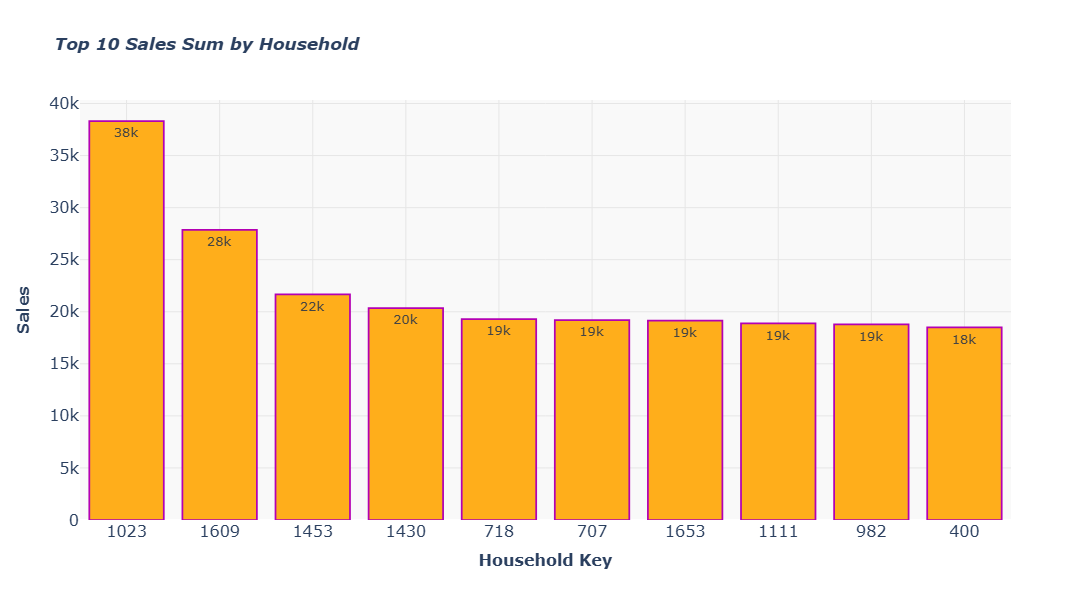

In [47]:
fig = px.bar(Top_10_Sales_Plotly,
              x= "household_key",
              y="SALES_VALUE",
              labels=dict(household_key="<b>Household Key</b>", SALES_VALUE="<b>Sales</b>"),
              text="SALES_VALUE",
              title="<b><i>Top 10 Sales Sum by Household</b></i>",
             
              color_discrete_sequence=["#ffae1b"])

fig.update_traces(width=0.8, 
                   marker_line_color="#b300b3",
                   marker_line_width=1.75,
                   texttemplate='%{text:.2s}',
                   textposition='inside',
                   textfont_size=13)
        
               
    
fig.update_layout(plot_bgcolor="#fafafa",
                  xaxis_title_font=dict(size=16),
                  yaxis_title_font=dict(size=16),
                  xaxis_type='category',
                  xaxis=dict(tickfont=dict(size=16)),
                  yaxis=dict(tickfont=dict(size=16)),
                  bargap=0.1,
                  width=1000,
                  height=600)

fig.update_layout(xaxis=dict(showgrid=True, gridcolor="#e6e6e6"),
                  yaxis=dict(showgrid=True, gridcolor="#e6e6e6"),
                  plot_bgcolor="#f9f9f9")
fig.show()
fig.write_image("Top 10 Sales Sum by Household.png", width=1200, height=800, scale=2) #Exporting the graph on .png file with code

<div>
<h3 style="color:#8dcf63"><i>**Key Insight:**</i></h3>
<h3>Visualizing the top households clearly demonstrates the spending hierarchy even among our best customers. The #1 household significantly outpaces the #10 household, reinforcing the need for tiered loyalty rewards.</h3>
</div>
<hr style="height:1px; background-color:black;">

<h2 style="text-align:center; background-color:#aeb067">Step 7: Product Analysis</h2>

<hr style="background-color:#94964e; height:2px; width:50%; margin-left:25%;">
<h3 style="text-align:center">Top 10 Products by Sales Value</h3>
<hr style="background-color:#94964e; height:2px; width:50%; margin-left:25%;">

In [48]:
Top10_Products =(df
                .groupby(["PRODUCT_ID"])[["SALES_VALUE"]]
                .sum()
                .sort_values(by=["SALES_VALUE"],ascending=False)
                .head(10))
                
Top10_Products_Plotly=Top10_Products.reset_index() 
Top10_Products

,SALES_VALUE
PRODUCT_ID,
6534178,420154.13
6533889,42339.31
1029743,33894.75
1082185,24149.79
6533765,23831.14
6534166,23755.70
1106523,22931.01
916122,22749.02
995242,21229.72


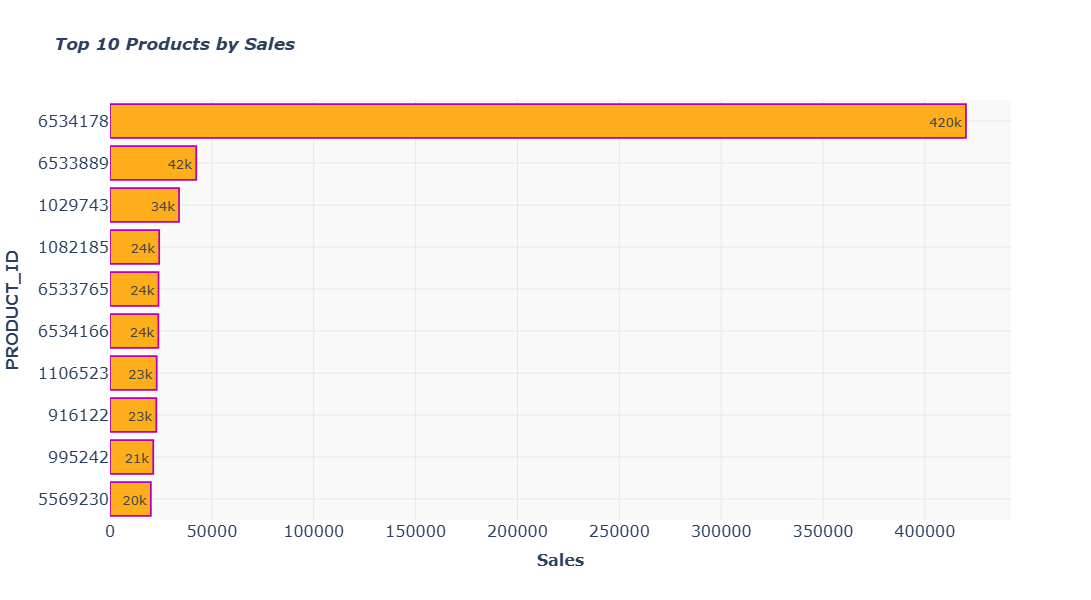

In [49]:
fig = px.bar(Top10_Products_Plotly,
              orientation="h",
              y= "PRODUCT_ID",
              x="SALES_VALUE",
              labels=dict(PRODUCT_ID="<b>PRODUCT_ID</b>", SALES_VALUE="<b>Sales</b>"),
              text="SALES_VALUE",
              title="<b><i>Top 10 Products by Sales</b></i>",
              color_discrete_sequence=["#ffae1b"])

fig.update_traces(width=0.8, 
                   marker_line_color="#b300b3",
                   marker_line_width=1.75,
                   texttemplate='%{text:.2s}',
                   textposition='inside',
                   textfont_size=13)
        
               
    
fig.update_layout(plot_bgcolor="#fafafa",
                  xaxis_title_font=dict(size=16),
                  yaxis_title_font=dict(size=16),
                  xaxis_type="linear",
                  yaxis_type="category",
                  xaxis=dict(tickfont=dict(size=16)),
                  yaxis=dict(tickfont=dict(size=16)),
                  bargap=0.1,
                  width=1000,
                  height=600)

fig.update_layout(xaxis=dict(tickformat="\\.2",showgrid=True, gridcolor="#e6e6e6"),
                  yaxis=dict({'categoryorder':'total ascending'},showgrid=True, gridcolor="#e6e6e6"),
                  plot_bgcolor="#f9f9f9")
fig.show()
fig.write_image("Top 10 Products by Sales.png", width=1200, height=800, scale=2) #Exporting the graph on .png file with code

<div>
<h3 style="color:#8dcf63"><i>**Key Insight:**</i></h3>
<h3>A small fraction of our product catalog is driving a massive portion of the revenue. Visualizing this heavily skewed distribution helps inventory managers prioritize stock levels for these specific high-value items.</h3>
</div>
<hr style="height:1px; background-color:black;">

<hr style="background-color:#94964e; height:2px; width:50%; margin-left:25%;">
<h3 style="text-align:center">Discount Rate of Top 10 Selling Items vs. Store Average</h3>
<hr style="background-color:#94964e; height:2px; width:50%; margin-left:25%;">

In [50]:
Top_10_Products_DicountRate=(df.query("PRODUCT_ID in @Top10_Products.index").loc[:,"Total_Discount"].sum()
/df.query("PRODUCT_ID in @Top10_Products.index").loc[:,"SALES_VALUE"].sum())

In [51]:
Average_DicountRate= df["Total_Discount"].sum() / df["SALES_VALUE"].sum()

In [81]:
print(f"The Discount Rate of the Top 10 selling items is {abs(Top_10_Products_DicountRate):.2%}\nThe average Discount Rate is {abs(Average_DicountRate):.2%}")

The Discount Rate of the Top 10 selling items is 10.33%
The average Discount Rate is 17.68%


<div>
<h3 style="color:#8dcf63"><i>**Key Insight:**</i></h3>
<h3>Comparing the discount rate of our best-sellers to the store average (17.68%) reveals our promotional efficiency. If top items have lower-than-average discounts, it means they are highly inelastic and drive organic revenue without needing markdowns!</h3>
</div>
<hr style="height:1px; background-color:black;">

<hr style="background-color:#94964e; height:2px; width:50%; margin-left:25%;">
<h3 style="text-align:center">Most Common Product Purchased by Top 10 Households</h3>
<hr style="background-color:#94964e; height:2px; width:50%; margin-left:25%;">

In [53]:
Top_10_Household=(df.query("household_key in @Top10_Sales.index")
                              .loc[:,"PRODUCT_ID"]
                              .value_counts()
                              .iloc[:10])
                              #.reset_index(name="Purchase_Count"))
Top_10_Household

PRODUCT_ID
1082185    576
1029743    573
6534178    561
6533889    418
1127831    230
951590     202
860776     184
1106523    178
981760     174
9677202    168
Name: count, dtype: int64

<hr style="background-color:#94964e; height:2px; width:50%; margin-left:25%;">
<h3 style="text-align:center">Top 10 Products: Product Name Lookup</h3>
<hr style="background-color:#94964e; height:2px; width:50%; margin-left:25%;">

In [54]:
Products_df=pd.read_csv("product.csv")
Products_df

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ
...,...,...,...,...,...,...,...
92348,18293142,6384,DRUG GM,National,BOOKSTORE,PAPERBACK BOOKS,
92349,18293439,6393,DRUG GM,National,BOOKSTORE,CHILDRENS LOW END,
92350,18293696,6406,DRUG GM,National,BOOKSTORE,PAPERBACK BEST SELLER,
92351,18294080,6442,DRUG GM,National,BOOKSTORE,PAPERBACK BOOKS,


In [55]:
Products_df.query("PRODUCT_ID in @Top_10_Household.index")

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
10630,860776,2,PRODUCE,National,VEGETABLES - ALL OTHERS,CUCUMBERS,36 CT
20973,951590,910,GROCERY,National,BAKED BREAD/BUNS/ROLLS,MAINSTREAM WHITE BREAD,20 OZ
24250,981760,69,GROCERY,Private,EGGS,EGGS - X-LARGE,1 DZ
29657,1029743,69,GROCERY,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,1 GA
35576,1082185,2,PRODUCE,National,TROPICAL FRUIT,BANANAS,40 LB
38262,1106523,69,GROCERY,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,1 GA
40600,1127831,5937,PRODUCE,National,BERRIES,STRAWBERRIES,16 OZ
57181,6533889,69,MISC SALES TRAN,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
57221,6534178,69,KIOSK-GAS,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
68952,9677202,69,GROCERY,Private,PAPER TOWELS,PAPER TOWELS & HOLDERS,


<div>
<h3 style="color:#ff9382"><i>**Data Engineering Note:**</i></h3>
<h3>While a standard Left Join is typical for combining datasets, we are intentionally using Pandas' <b>.query()</b> method with the <b>@</b> symbol here. This showcases a highly readable, memory-efficient technique for filtering a table based on an external variable (like an index) before heavier SQL-style joins become strictly necessary.</h3>
</div>
<hr style="height:1px; background-color:black;">

<hr style="background-color:#94964e; height:2px; width:50%; margin-left:25%;">
<h3 style="text-align:center">Identifying the Maximum Quantity Outlier</h3>
<hr style="background-color:#94964e; height:2px; width:50%; margin-left:25%;">

In [56]:
Top10_Quantity =(df
                .groupby(["PRODUCT_ID"])[["QUANTITY"]]
                .sum()
                .sort_values(by=["QUANTITY"],ascending=False)
                .head(5))

Top10_Quantity

,QUANTITY
PRODUCT_ID,
6534178,180705254
6533889,16904944
6534166,9880540
6544236,2400961
397896,1181305


In [57]:
Top10_QuantityProduct_Names=Top10_Quantity.merge(Products_df, on="PRODUCT_ID", how="left")
Top10_QuantityProduct_Names

,PRODUCT_ID,QUANTITY,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,6534178,180705254,69,KIOSK-GAS,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
1,6533889,16904944,69,MISC SALES TRAN,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
2,6534166,9880540,69,MISC SALES TRAN,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
3,6544236,2400961,69,MISC SALES TRAN,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
4,397896,1181305,69,KIOSK-GAS,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,


<div>
<h3 style="color:#8dcf63"><i>**Key Insight:**</i></h3>
<h3>As hypothesized in Step 3, looking up the product name confirms that the massive 89,638-unit transaction was indeed <b>Gasoline</b>. This closes the loop on our anomaly detection and proves the data is accurate.</h3>
</div>
<hr style="height:1px; background-color:black;">

<h2 style="text-align:center; background-color: #ffd182">Step 8: Customer Demographic Profiling</h2>  


In [58]:
Demogs=pd.read_csv("hh_demographic.csv", usecols=["AGE_DESC", "INCOME_DESC", "household_key","HH_COMP_DESC"])
Demogs

,AGE_DESC,INCOME_DESC,HH_COMP_DESC,household_key
0,65+,35-49K,2 Adults No Kids,1
1,45-54,50-74K,2 Adults No Kids,7
2,25-34,25-34K,2 Adults Kids,8
3,25-34,75-99K,2 Adults Kids,13
4,45-54,50-74K,Single Female,16
...,...,...,...,...
796,35-44,50-74K,2 Adults No Kids,2494
797,45-54,75-99K,Unknown,2496
798,45-54,35-49K,Single Male,2497
799,25-34,50-74K,2 Adults No Kids,2498


In [59]:
Demogs.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   AGE_DESC       801 non-null    str  
 1   INCOME_DESC    801 non-null    str  
 2   HH_COMP_DESC   801 non-null    str  
 3   household_key  801 non-null    int64
dtypes: int64(1), str(3)
memory usage: 140.5 KB


In [60]:
Demogs[["AGE_DESC", "INCOME_DESC","HH_COMP_DESC"]].nunique()/len(Demogs)*100

AGE_DESC       0.75
INCOME_DESC    1.50
HH_COMP_DESC   0.75
dtype: float64

<div>
<h3 style="color:#ff9382"><i>**Data Engineering Note:**</i></h3>
<h3>As observed, <b>AGE_DESC</b>, <b>INCOME_DESC</b>, and <b>HH_COMP_DESC</b> are highly repeatable descriptive data points. Converting them to a `category` type will optimize our merge performance.</h3></div>
<hr style= "height:1px; background-color:black;">

In [61]:
Demogs=Demogs.astype({"AGE_DESC":"category","INCOME_DESC":"category","HH_COMP_DESC":"category","household_key":"int16"})
Demogs.info()

<class 'pandas.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   AGE_DESC       801 non-null    category
 1   INCOME_DESC    801 non-null    category
 2   HH_COMP_DESC   801 non-null    category
 3   household_key  801 non-null    int16   
dtypes: category(3), int16(1)
memory usage: 4.2 KB


<hr style="background-color:#ffbe4f; height:2px; width:50%; margin-left:22.5%">
<h3 style="text-align:center">Aggregating Transactions by Household</h3>
<hr style="background-color:#ffbe4f; height:2px; width:50%; margin-left:22.5%">

In [62]:
Gcols=df.groupby(["household_key"])[["SALES_VALUE"]].sum()
Gcols

,SALES_VALUE
household_key,
1,4330.16
2,1954.34
3,2653.21
4,1200.11
5,779.06
...,...
2095,3790.49
2096,1301.65
2097,8823.83


<hr style="background-color:#ffbe4f; height:2px; width:50%; margin-left:22.5%">
<h3 style="text-align:center">Merging Household Demographics</h3>
<hr style="background-color:#ffbe4f; height:2px; width:50%; margin-left:22.5%">

In [63]:
Sales_Demogs=Gcols.merge(Demogs,
                            how="inner",
                            right_on=["household_key"],
                            left_on=["household_key"])
Sales_Demogs

,household_key,SALES_VALUE,AGE_DESC,INCOME_DESC,HH_COMP_DESC
0,1,4330.16,65+,35-49K,2 Adults No Kids
1,7,3400.05,45-54,50-74K,2 Adults No Kids
2,8,5534.97,25-34,25-34K,2 Adults Kids
3,13,13190.92,25-34,75-99K,2 Adults Kids
4,16,1512.02,45-54,50-74K,Single Female
...,...,...,...,...,...
663,2087,7832.74,45-54,100-124K,Unknown
664,2088,4905.71,25-34,35-49K,Single Female
665,2092,2290.54,35-44,Under 15K,1 Adult Kids
666,2094,3055.52,45-54,50-74K,2 Adults No Kids


<hr style="background-color:#ffbe4f; height:2px; width:50%; margin-left:22.5%">
<h3 style="text-align:center">Sales Distribution by Age and Income Bracket</h3>
<hr style="background-color:#ffbe4f; height:2px; width:50%; margin-left:22.5%">

In [64]:
SbAI=(Sales_Demogs.groupby(["AGE_DESC","INCOME_DESC"])[["SALES_VALUE"]]
                    .sum()
                    .reset_index())
SbAI

,AGE_DESC,INCOME_DESC,SALES_VALUE
0,19-24,15-24K,14577.39
1,19-24,200-249K,2206.06
2,19-24,25-34K,16083.13
3,19-24,250K+,11938.20
4,19-24,35-49K,42379.96
...,...,...,...
56,65+,25-34K,18937.05
57,65+,35-49K,76463.48
58,65+,50-74K,57286.53
59,65+,75-99K,31936.80


<hr style= "height:1px; background-color:black;">
<div>
<h3 style="color:#ff9382"><i>**Data Engineering Note:**</i></h3>
<h3>By default, Pandas sorts categorical text data alphabetically. To ensure the age and income brackets render in their proper sequential order on the bar chart (rather than alphabetically), we explicitly ordered the categorical bins prior to visualization.</h3></div>

In [65]:
SbAI["INCOME_DESC"].unique()

['15-24K', '200-249K', '25-34K', '250K+', '35-49K', ..., 'Under 15K', '100-124K', '125-149K', '150-174K', '175-199K']
Length: 12
Categories (12, str): ['100-124K', '125-149K', '15-24K', '150-174K', ..., '35-49K', '50-74K', '75-99K', 'Under 15K']

In [66]:
SbAI["AGE_DESC"].unique()

['19-24', '25-34', '35-44', '45-54', '55-64', '65+']
Categories (6, str): ['19-24', '25-34', '35-44', '45-54', '55-64', '65+']

In [67]:
age_order = [
    "19-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

income_order = [
    "Under 15K",
    "15-24K",
    "25-34K",
    "35-49K",
    "50-74K",
    "75-99K",
    "100-124K",
    "125-149K",
    "150-174K",
    "175-199K",
    "200-249K",
    "250K+"
]


In [68]:
SbAI["AGE_DESC"] = pd.Categorical(SbAI["AGE_DESC"], categories=age_order, ordered=True)

SbAI["INCOME_DESC"] = pd.Categorical(SbAI["INCOME_DESC"], categories=income_order, ordered=True)

<hr style= "height:1px; background-color:black;">

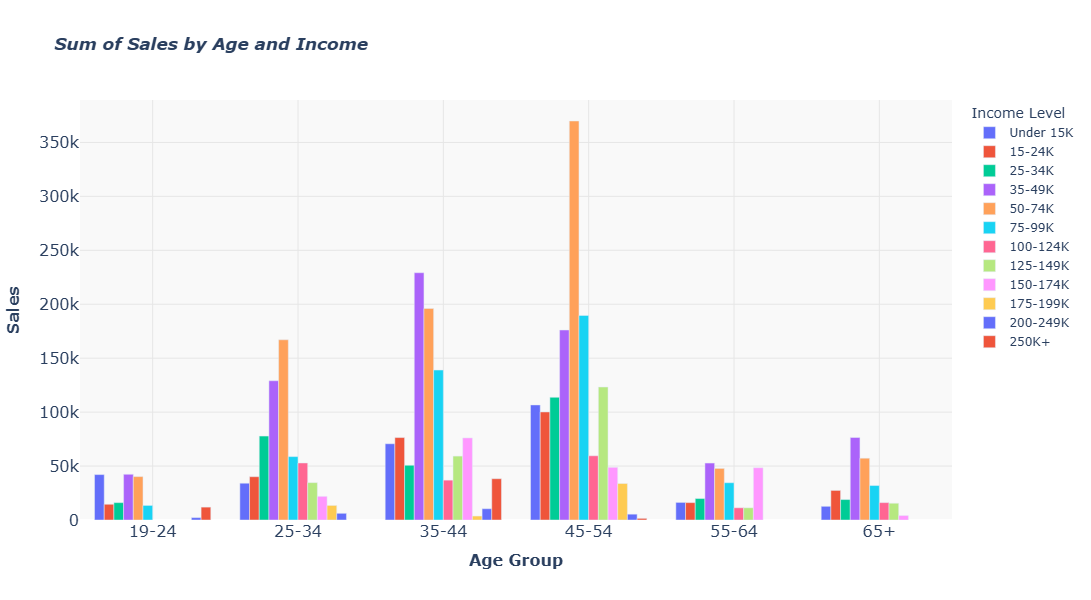

Resorting to unclean kill browser.


In [69]:
fig = px.bar(SbAI,
             x="AGE_DESC",
             y="SALES_VALUE",
             color="INCOME_DESC",
             barmode="group",
             category_orders={"AGE_DESC": age_order,"INCOME_DESC": income_order},
             labels=dict(AGE_DESC="<b>Age Group</b>", SALES_VALUE="<b>Sales</b>"),
             title="<b><i>Sum of Sales by Age and Income</b></i>",)

fig.update_layout(plot_bgcolor="#fafafa",
                  xaxis_title_font=dict(size=16),
                  yaxis_title_font=dict(size=16),
                  xaxis=dict(tickfont=dict(size=16)),
                  yaxis=dict(tickfont=dict(size=16)),
                  legend_title_text="Income Level",
                  width=1000,
                  height=600)

fig.update_layout(xaxis=dict(showgrid=True, gridcolor="#e6e6e6"),
                  yaxis=dict(showgrid=True, gridcolor="#e6e6e6"),
                  plot_bgcolor="#f9f9f9")

fig.show()
fig.write_image("Sales by Age and Icome Brackets.png",
                width=1200, 
                height=800, 
                scale=2) #Exporting the graph on .png file with code

<div>
<h3 style="color:#8dcf63"><i>**Key Insight:**</i></h3>
<h3>Breaking down total sales by both age and income reveals our core customer base. The visualizations indicate that the <b>50-74k</b> income bracket within the <b>45-54</b> age group drives the most revenue.</h3></div>
<hr style= "height:1px;background-color:black;"> 

<hr style="background-color:#ffbe4f; height:2px; width:50%; margin-left:22.5%">
<h3 style="text-align:center">Average Household Spend by Age & Composition (Pivot Table HeatMap)</h3>
<hr style="background-color:#ffbe4f; height:2px; width:50%; margin-left:22.5%">

In [70]:
Sales_Pivot=Sales_Demogs.pivot_table(index=("AGE_DESC"),
                                     columns=("HH_COMP_DESC"),      
                                     aggfunc=("mean"),
                                     values=("SALES_VALUE"))
Sales_Pivot 

HH_COMP_DESC,1 Adult Kids,2 Adults Kids,2 Adults No Kids,Single Female,Single Male,Unknown
AGE_DESC,,,,,,
19-24,7268.80,5428.94,4020.80,4576.10,3216.84,4911.27
25-34,5512.20,5753.97,5638.52,4807.44,4909.52,7356.27
35-44,6297.74,6691.77,6260.41,6015.19,4844.19,4227.69
45-54,6632.57,6610.48,5839.53,4549.37,4636.64,4844.00
55-64,3064.87,4695.65,5752.41,4816.15,3922.55,7973.75
65+,4040.81,5536.87,4614.11,4059.70,3871.56,2879.29


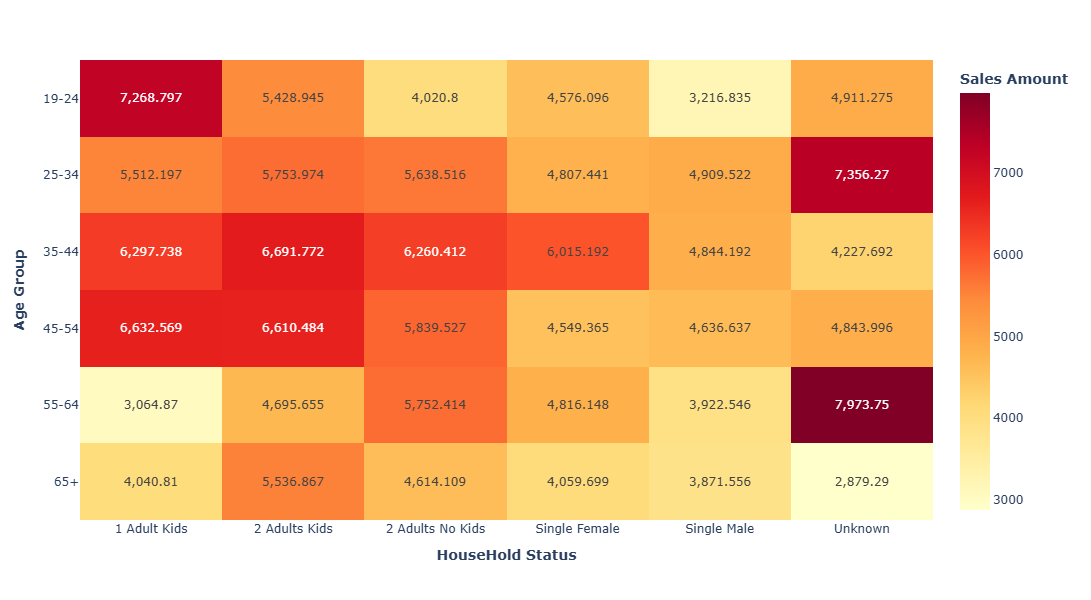

In [71]:
fig = px.imshow(Sales_Pivot,
                labels=dict(x="<b>HouseHold Status</b>", y="<b>Age Group</b>", color="<b>Sales Amount</b>"),
                text_auto=True,
                aspect="auto",
                color_continuous_scale="YlOrRd")

fig.update_layout(width=1000, height=600)

fig.show()
fig.write_image("Sales by Household Status and Age group_HEATMAP.png", 
                width=1200, 
                height=800,
                scale=2) #Exporting the graph on .png file 

<div>
<h3 style="color:#8dcf63"><i>**Key Insight:**</i></h3>
<h3>By looking at 'average' sales rather than 'total' sales, we can identify which specific household types have the highest individual purchasing power. Families from <b>Unkown Type</b> and age <b>55-64</b> spend the most per household, making them the ideal target for premium product upselling.</h3></div>
<hr style= "height:1px; background-color:black;"> 

<h2 style="text-align:center; background-color: #edcfff">Step 9: Product Category & Demographic Intersection</h2>  

<hr style="background-color:#d083ff; height:2px; width:50%; margin-left:22.5%">
<h3 style="text-align:center">Merging Product & Transaction Data</h3>
<hr style="background-color:#d083ff; height:2px; width:50%; margin-left:22.5%">

In [72]:
Products=pd.read_csv("product.csv", usecols=["PRODUCT_ID","DEPARTMENT"])
Products

,PRODUCT_ID,DEPARTMENT
0,25671,GROCERY
1,26081,MISC. TRANS.
2,26093,PASTRY
3,26190,GROCERY
4,26355,GROCERY
...,...,...
92348,18293142,DRUG GM
92349,18293439,DRUG GM
92350,18293696,DRUG GM
92351,18294080,DRUG GM


In [73]:
Products.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 92353 entries, 0 to 92352
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   PRODUCT_ID  92353 non-null  int64
 1   DEPARTMENT  92353 non-null  str  
dtypes: int64(1), str(1)
memory usage: 5.6 MB


In [74]:
Products[["PRODUCT_ID","DEPARTMENT"]].nunique()/len(Products)*100

PRODUCT_ID   100.00
DEPARTMENT     0.05
dtype: float64

In [75]:
Products=Products.astype({"PRODUCT_ID":"int32","DEPARTMENT":"category" })

In [76]:
Products.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 92353 entries, 0 to 92352
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   PRODUCT_ID  92353 non-null  int32   
 1   DEPARTMENT  92353 non-null  category
dtypes: category(1), int32(1)
memory usage: 453.6 KB


In [77]:
ProdutsJOIN=Products.set_index("PRODUCT_ID").join(df.set_index("PRODUCT_ID"),how="inner").reset_index()
ProdutsJOIN

,PRODUCT_ID,DEPARTMENT,household_key,BASKET_ID,QUANTITY,SALES_VALUE,STORE_ID,WEEK_NO,date,Total_Discount,Percentage_Discount
0,25671,GROCERY,1228,29046618323,1,3.49,3313,23,2016-06-05,0.00,0.00
1,25671,GROCERY,358,30707611686,1,3.49,3266,36,2016-09-03,0.00,0.00
2,25671,GROCERY,325,33046710871,4,13.96,3191,59,2017-02-13,0.00,0.00
3,26081,MISC. TRANS.,1675,30760265177,1,0.99,3235,36,2016-09-06,0.00,0.00
4,26093,PASTRY,1032,33783848749,1,1.59,33904,66,2017-04-02,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...
2146306,18292005,GROCERY,119,42263205047,2,4.38,334,102,2017-12-09,0.00,0.00
2146307,18293142,DRUG GM,1947,42276190904,1,7.19,32004,102,2017-12-10,0.00,0.00
2146308,18293439,DRUG GM,2022,42172795382,1,7.19,438,101,2017-12-02,0.00,0.00
2146309,18293696,DRUG GM,2070,42263426957,1,4.79,311,102,2017-12-09,0.00,0.00


In [78]:
FinalDF=ProdutsJOIN.set_index("household_key").join(Demogs.set_index("household_key"),how="inner").reset_index()
FinalDF

,household_key,PRODUCT_ID,DEPARTMENT,BASKET_ID,QUANTITY,SALES_VALUE,STORE_ID,WEEK_NO,date,Total_Discount,Percentage_Discount,AGE_DESC,INCOME_DESC,HH_COMP_DESC
0,1228,25671,GROCERY,29046618323,1,3.49,3313,23,2016-06-05,0.00,0.00,45-54,100-124K,Single Female
1,358,25671,GROCERY,30707611686,1,3.49,3266,36,2016-09-03,0.00,0.00,35-44,50-74K,2 Adults No Kids
2,325,25671,GROCERY,33046710871,4,13.96,3191,59,2017-02-13,0.00,0.00,35-44,75-99K,2 Adults Kids
3,997,26601,DRUG GM,29224467440,1,7.59,3182,25,2016-06-16,0.00,0.00,45-54,75-99K,Single Male
4,212,26636,PASTRY,35469987050,1,2.50,3163,75,2017-06-05,-0.79,0.32,35-44,Under 15K,Single Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1161570,670,18253088,DRUG GM,42135817459,1,4.99,372,101,2017-11-29,0.00,0.00,55-64,35-49K,2 Adults Kids
1161571,2004,18273115,DRUG GM,42229362287,3,0.75,31782,102,2017-12-06,0.00,0.00,45-54,50-74K,Unknown
1161572,119,18292005,GROCERY,42263205047,2,4.38,334,102,2017-12-09,0.00,0.00,45-54,125-149K,Single Male
1161573,2070,18293696,DRUG GM,42263426957,1,4.79,311,102,2017-12-09,0.00,0.00,45-54,50-74K,Unknown


<div>
<h3 style="color:#cfca63"><i>**Data Engineering Insight:**</i></h3>
<h3>To understand 'what' our demographics are buying, we introduce the <b>product.csv</b> dataset, merging it into our main transaction table using <b>PRODUCT_ID</b>.</h3></div>
<hr style= "height:1px; background-color:black;">

<hr style="background-color:#d083ff; height:2px; width:50%; margin-left:22.5%">
<h3 style="text-align:center">Matrix of Total Sales: Product Category vs. Age Group</h3>
<hr style="background-color:#d083ff; height:2px; width:50%; margin-left:22.5%">

In [79]:
FinalPIVOT=FinalDF.pivot_table(index="DEPARTMENT",
                               columns="AGE_DESC",
                               values="SALES_VALUE",
                               aggfunc="sum",
                               margins=True)

FinalPIVOT=(FinalPIVOT.sort_values(by="All", ascending=False)
                      .drop("All",axis=0)
                      .rename(columns={"All":"TOTAL_SALES"})
                      .fillna(0))                             # We fill NaN values with '0' for excel use
FinalPIVOT

AGE_DESC,19-24,25-34,35-44,45-54,55-64,65+,TOTAL_SALES
DEPARTMENT,,,,,,,
GROCERY,99008.27,327926.16,490616.03,667162.98,127082.01,129117.27,1840912.72
DRUG GM,25297.43,85298.05,126480.34,177007.13,29220.93,32759.76,476063.64
KIOSK-GAS,8465.18,50817.91,92614.66,96858.44,16329.77,17853.99,282939.95
PRODUCE,10170.59,41706.46,67779.89,96442.73,21326.15,23295.78,260721.60
MEAT,11957.34,37162.66,61003.95,87407.67,20001.91,17514.19,235047.72
MEAT-PCKGD,10453.13,30029.69,46499.11,59855.46,11891.43,10413.65,169142.47
DELI,4043.30,18181.94,34577.29,44334.22,9850.54,10462.33,121449.62
MISC SALES TRAN,2031.73,8200.66,9976.19,23617.85,7762.98,2657.76,54247.17
PASTRY,2386.73,8161.42,13706.81,19534.79,3601.86,5162.80,52554.41


<div>
<h3 style="color:#8dcf63"><i>**Key Insight:**</i></h3>
<h3>This multi-dimensional pivot table cross-references departmental product categories with age groups. Sorting this table allows us to immediately identify the most popular product lines for any given age group.</h3></div>
<hr style= "height:1px; background-color:black;"> 

<h2 style="text-align:center; background-color:#f2ff9b">Step 10: Data Export for Stakeholder Review</h2>  

<div>
<h3 style="color:#8dcf63"><i>**Key Insight:**</i></h3>
<h3>By merging demographic data with transaction logs, we identified our most valuable customer segments. The final pivot table aggregates average sales by Age and Household Composition, allowing the marketing team to target future campaigns directly toward high-spending groups. The finalized data model is exported to Excel below for stakeholder distribution.</h3></div>
<hr style= "height:1px; background-color:black;"> 

In [80]:
FinalPIVOT.columns = pd.MultiIndex.from_product([["SALES SUM BY PRODUCT CATEGORY AND AGE"], FinalPIVOT.columns])
with pd.ExcelWriter("Sales sum by Product category and Age.xlsx", engine="xlsxwriter")as writer:

    FinalPIVOT.to_excel(writer, sheet_name="Pivot table")

    workbook = writer.book
    worksheet = writer.sheets["Pivot table"]

    euro_format = workbook.add_format({'num_format': '€#,##0.00'}) # Define the Euro currency format

    worksheet.set_column(0, 0, 25) # Set Department names (first column) to a width of 25
    worksheet.set_column(1, FinalPIVOT.shape[1], 15, euro_format) # Set all Data columns to a uniform width of 15 and apply Euro format
    worksheet.freeze_panes(2, 1) # Freeze the top 2 header rows and the first column for easy scrolling
    



<div>
<h3 style="color:#ff9382"><i>**Data Engineering Note:**</i></h3>
<h3>To ensure the final Excel deliverable is polished and immediately readable for stakeholders, we utilize the `xlsxwriter` engine to inject Euro currency formatting. We also manually set uniform column widths to prevent the rendering errors (like ####), that often occur when exporting wide financial formats to Excel.</h3></div>
<hr style= "height:1px; background-color:black;">